In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

data = pd.read_csv(
    "./iris.data",
    names=columns
)

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
print(data.shape)
print(data.info())
print(data["species"].value_counts())

(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [9]:
X = data.drop("species", axis=1)
y = data["species"]
print(X.shape)
print(y.shape)

(150, 4)
(150,)


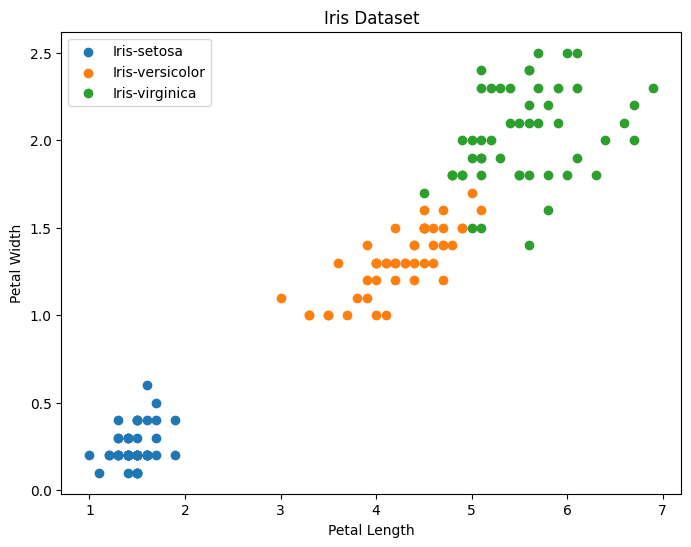

In [10]:
plt.figure(figsize=(8, 6))

for species in data["species"].unique():

    subset = data[data["species"] == species]

    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=species
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset")
plt.legend()
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# StandardScaler = features ki values ko standard scale par convert karta hai, taaki ek feature sirf bade numbers ki wajah se dominate na kare.
scaler = StandardScaler()

# fit()       → learns Mean + Standard Deviation
# transform() → standardizes the data using Mean + Std

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
print(X_train_scaled)

[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]
 [ 0.54731923 -1.22612948  0.6983752   0.91480554]
 [-0.2885865  -0.77548465  0.24383948  0.12599118]
 [ 0.54731923 -0.55016223  0.75519216  0.3889293 ]
 [ 2.21913069 -0.0995174   1.32336182  1.44068178]
 [ 2.21913069  1.70306192  1.66426361  1.30921272]
 [ 2.09971558 -0.0995174   1.60744665  1.17774366]
 [ 0.18907392 -0.32483982  0.41429037  0.3889293 ]
 [-1.00507713 -2.35274155 -0.15387928 -0.268416  ]
 [-0.04975629 -0.77548465  0.18702251 -0.268416  ]
 [-0.04975629 -1.00080706  0.13020555 -0.00547788]
 [-1.36332244  0.35112743 -1.23340162 -1.32016847]
 [-0.88566202  1.70306192 -1.29021859 -1.18869941]
 [ 1.02497964 -1.22612948  1.15291092  0.78333648]
 [ 0.66673433  0.12580502  0.98246003  0.78333648]
 [-0.52741671  0.80177226 -1.29

In [16]:
linear_svm = SVC(
    kernel="linear",
    C=1
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
y_pred = linear_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [18]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [19]:
print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [20]:
print("Support vectors per class:")
print(linear_svm.n_support_)


Support vectors per class:
[ 2 11 10]


In [21]:
print("Total support vectors:")
print(len(linear_svm.support_))


Total support vectors:
23


In [22]:
print(linear_svm.support_vectors_)


[[-1.60215265 -1.67677431 -1.40385252 -1.18869941]
 [-0.88566202  0.57644985 -1.17658466 -0.92576129]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [ 0.18907392 -0.32483982  0.41429037  0.3889293 ]
 [ 0.54731923 -1.22612948  0.64155823  0.3889293 ]
 [ 0.06965881  0.35112743  0.58474127  0.78333648]
 [ 0.18907392 -0.77548465  0.75519216  0.52039836]
 [-0.2885865  -0.0995174   0.41429037  0.3889293 ]
 [ 0.78614944 -0.55016223  0.47110734  0.3889293 ]
 [ 0.18907392  0.80177226  0.41429037  0.52039836]
 [ 0.42790412 -1.90209672  0.41429037  0.3889293 ]
 [-0.88566202 -1.22612948 -0.43796411 -0.13694694]
 [ 1.26380985  0.12580502  0.64155823  0.3889293 ]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 0.54731923 -1.22612948  0.6983752   0.91480554]
 [ 0.54731923 -0.55016223  0.75519216  0.3889293 ]
 [ 0.66673433  0.12580502  0.98246003  0.78333648]
 [ 0.06965881 -0.0995174   0.75519216  0.78333648]
 [ 0.18907392 -1.90209672  0.6983752   0.3889293 ]
 [ 1.62205517 -0.0995174   1.15

# Visualizing the   boundary 


In [23]:
X_2d = data[
    ["petal_length", "petal_width"]
]

y_2d = data["species"]


X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)

X2_test_scaled = scaler_2d.transform(X2_test)

In [24]:
svm_2d = SVC(
    kernel="linear",
    C=1
)

svm_2d.fit(
    X2_train_scaled,
    y2_train
)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
def plot_svm_regions(model, X, y, title):

    X_array = np.asarray(X)

    x_min = X_array[:, 0].min() - 1
    x_max = X_array[:, 0].max() + 1

    y_min = X_array[:, 1].min() - 1
    y_max = X_array[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(grid)

    classes = model.classes_

    class_to_number = {
        cls: i
        for i, cls in enumerate(classes)
    }

    Z = np.array([
        class_to_number[p]
        for p in predictions
    ])

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 7))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.2
    )

    for cls in classes:

        mask = np.array(y) == cls

        plt.scatter(
            X_array[mask, 0],
            X_array[mask, 1],
            label=cls,
            s=50
        )

    # Support vectors
    support = model.support_vectors_

    plt.scatter(
        support[:, 0],
        support[:, 1],
        s=180,
        facecolors="none",
        linewidths=2,
        label="Support Vectors"
    )

    plt.xlabel("Petal Length (scaled)")
    plt.ylabel("Petal Width (scaled)")
    plt.title(title)
    plt.legend()
    plt.show()

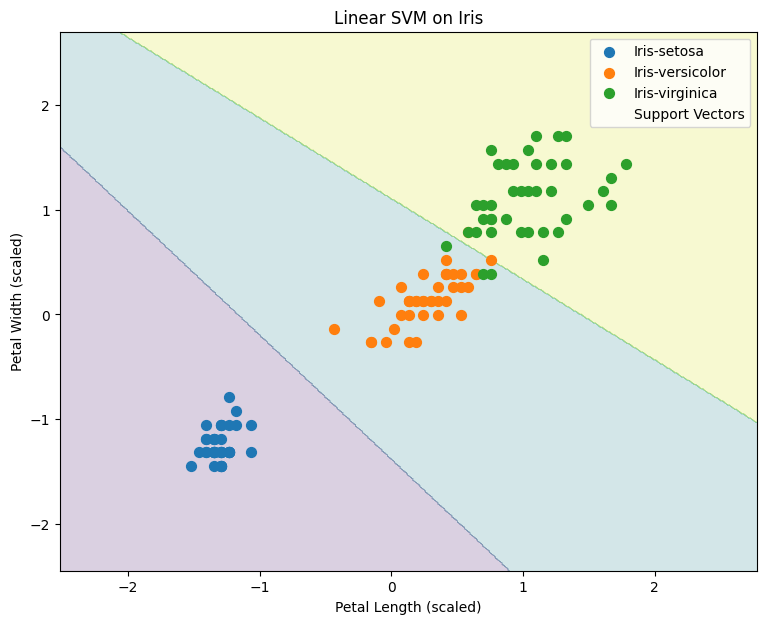

In [26]:
plot_svm_regions(
    svm_2d,
    X2_train_scaled,
    y2_train,
    "Linear SVM on Iris"
)

# Experiment with C

In [27]:
C_values = [
    0.01,
    0.1,
    1,
    10,
    100
]

for C in C_values:

    model = SVC(
        kernel="linear",
        C=C
    )

    model.fit(
        X2_train_scaled,
        y2_train
    )

    print(
        f"C = {C}"
    )

    print(
        "Train:",
        model.score(
            X2_train_scaled,
            y2_train
        )
    )

    print(
        "Test:",
        model.score(
            X2_test_scaled,
            y2_test
        )
    )

    print(
        "Support vectors:",
        len(model.support_)
    )

    print()

C = 0.01
Train: 0.9666666666666667
Test: 0.9333333333333333
Support vectors: 117

C = 0.1
Train: 0.9666666666666667
Test: 0.9333333333333333
Support vectors: 63

C = 1
Train: 0.9666666666666667
Test: 0.9333333333333333
Support vectors: 25

C = 10
Train: 0.9583333333333334
Test: 0.9333333333333333
Support vectors: 14

C = 100
Train: 0.9583333333333334
Test: 0.9333333333333333
Support vectors: 12



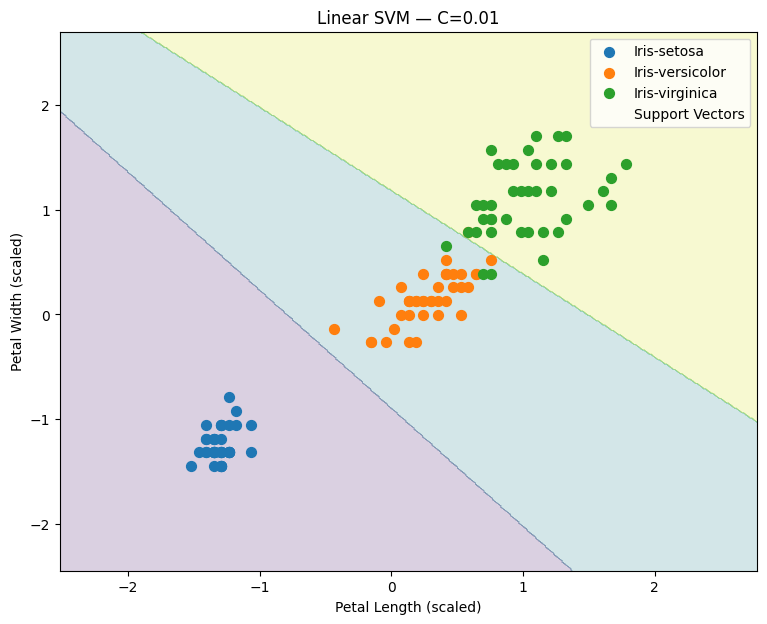

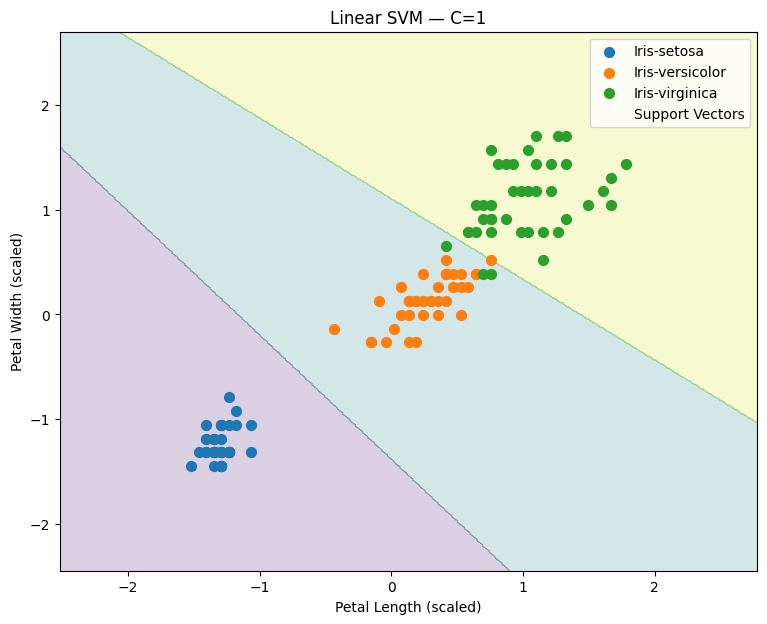

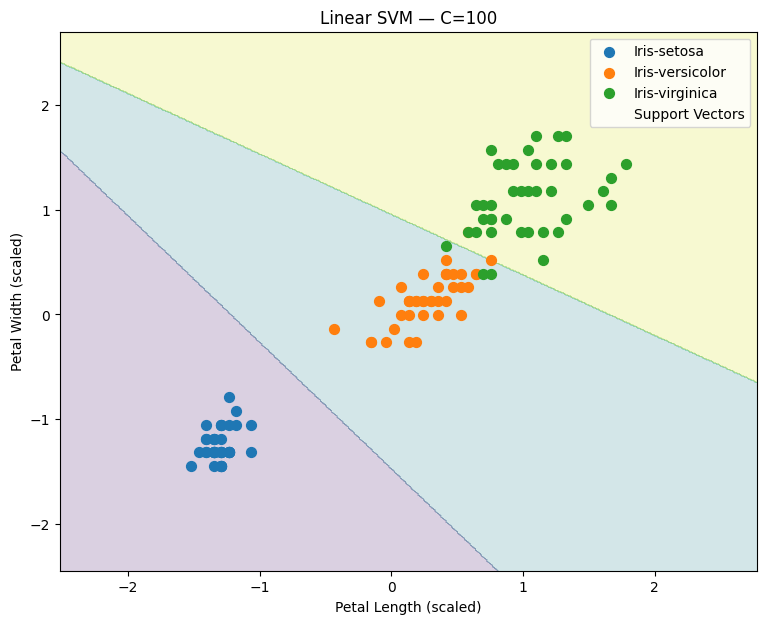

In [28]:
for C in [0.01, 1, 100]:

    model = SVC(
        kernel="linear",
        C=C
    )

    model.fit(
        X2_train_scaled,
        y2_train
    )

    plot_svm_regions(
        model,
        X2_train_scaled,
        y2_train,
        f"Linear SVM — C={C}"
    )